# Job Recommendation System
## Step 6: Compute Similarity & Matching

**Internship Project** | Gamage Recruiters  
**Focus:** Recruitment & HR / Data Science & Machine Learning

---

In Step 4 we built a recommendation engine using **TF-IDF cosine similarity** as the primary matching signal.  
In Step 5 we explored **Word2Vec embeddings** as an alternative feature representation.

In this step we go further — **rigorously comparing multiple distance / similarity metrics** across both feature spaces, building a **hybrid scoring model**, and providing a clean API for per-candidate and per-job lookups.

| Section | What we do |
|---|---|
| **Cosine Similarity** | Re-compute and inspect TF-IDF cosine scores |
| **Euclidean Distance** | Compute L2 distance, convert to similarity |
| **Pearson Correlation** | Row-wise correlation as a third metric |
| **W2V Cosine** | Word2Vec cosine for semantic comparison |
| **Metric Comparison** | Correlation between metrics, score distributions |
| **Hybrid Score** | Weighted blend of TF-IDF + W2V + structural bonuses |
| **Top-N Ranking** | Final ranked recommendations per candidate |
| **Job-Side Lookup** | Which candidates best match a given job posting |
| **Outputs** | CSV files + numpy matrices saved for Step 7 |


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics.pairwise import (
    cosine_similarity,
    euclidean_distances
)

plt.rcParams.update({'figure.dpi': 110, 'font.family': 'sans-serif'})
os.makedirs('../outputs', exist_ok=True)

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load All Artifacts from Steps 3–5

In [2]:
# ── DataFrames ────────────────────────────────────────────────────────────
df_c = pd.read_csv('../data/candidates_preprocessed.csv')
df_j = pd.read_csv('../data/job_postings_preprocessed.csv')

# ── TF-IDF sparse matrices (from Step 3) ─────────────────────────────────
candidate_tfidf = sp.load_npz('../models/candidate_tfidf_matrix.npz')
job_tfidf       = sp.load_npz('../models/job_tfidf_matrix.npz')

# ── Word2Vec dense embeddings (from Step 5) ───────────────────────────────
cand_embeddings = np.load('../models/candidate_w2v_embeddings.npy')
job_embeddings  = np.load('../models/job_w2v_embeddings.npy')

# ── Encoders & structural metadata (from Step 3) ──────────────────────────
with open('../models/encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
exp_order = encoders['exp_order']

print(f'Candidates         : {df_c.shape[0]} rows x {df_c.shape[1]} cols')
print(f'Job Postings       : {df_j.shape[0]} rows x {df_j.shape[1]} cols')
print(f'Candidate TF-IDF   : {candidate_tfidf.shape}  (sparse)')
print(f'Job TF-IDF         : {job_tfidf.shape}  (sparse)')
print(f'Candidate W2V      : {cand_embeddings.shape}  (dense)')
print(f'Job W2V            : {job_embeddings.shape}  (dense)')

Candidates         : 500 rows x 22 cols
Job Postings       : 200 rows x 26 cols
Candidate TF-IDF   : (500, 300)  (sparse)
Job TF-IDF         : (200, 300)  (sparse)
Candidate W2V      : (500, 100)  (dense)
Job W2V            : (200, 100)  (dense)


## 3. Metric 1 — Cosine Similarity (TF-IDF)

Cosine similarity measures the **angle** between two vectors, ignoring magnitude.  
It is the industry-standard metric for sparse TF-IDF vectors because it is not affected by document length.

$$\text{cosine\_sim}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

Range: **0** (no overlap) → **1** (identical profiles)

In [3]:
# Compute (500 x 200) cosine similarity matrix from TF-IDF vectors
tfidf_cosine = cosine_similarity(candidate_tfidf, job_tfidf)

print(f'TF-IDF Cosine Similarity Matrix : {tfidf_cosine.shape}')
print(f'Score range : {tfidf_cosine.min():.4f}  →  {tfidf_cosine.max():.4f}')
print(f'Mean score  : {tfidf_cosine.mean():.4f}')
print(f'Std dev     : {tfidf_cosine.std():.4f}')
print()
print('Sample — Candidate 0 vs first 5 jobs:')
for k in range(5):
    print(f'  vs {df_j["job_title"].iloc[k]:<35} [{df_j["industry"].iloc[k]:<12}]  score: {tfidf_cosine[0, k]:.4f}')

TF-IDF Cosine Similarity Matrix : (500, 200)
Score range : 0.0000  →  0.7578
Mean score  : 0.0716
Std dev     : 0.1105

Sample — Candidate 0 vs first 5 jobs:
  vs Financial Analyst                   [Finance     ]  score: 0.0000
  vs Full Stack Developer                [Technology  ]  score: 0.2372
  vs Operations Manager                  [Operations  ]  score: 0.0136
  vs Project Manager                     [Operations  ]  score: 0.0000
  vs Compensation Analyst                [HR          ]  score: 0.0000


## 4. Metric 2 — Euclidean Distance (TF-IDF)

Euclidean distance measures the **straight-line distance** between two vectors in feature space.  
Unlike cosine similarity, it is sensitive to vector magnitude — longer skill lists get penalised.  
We convert distance to a **similarity score** by applying the formula:

$$\text{euclidean\_sim}(A, B) = \frac{1}{1 + d(A, B)}$$

Range: **0** (very far apart) → **1** (identical)

In [5]:
# Compute Euclidean distance on the dense version of TF-IDF matrices
# (converting sparse to dense is required for euclidean_distances)
cand_tfidf_dense = candidate_tfidf.toarray()
job_tfidf_dense  = job_tfidf.toarray()

euc_dist = euclidean_distances(cand_tfidf_dense, job_tfidf_dense)   # (500, 200)

# Convert distance → similarity score
euc_sim = 1 / (1 + euc_dist)

print(f'Euclidean Distance Matrix shape : {euc_dist.shape}')
print(f'Distance range   : {euc_dist.min():.4f}  ->  {euc_dist.max():.4f}')
print()
print(f'Euclidean Similarity Matrix shape : {euc_sim.shape}')
print(f'Similarity range : {euc_sim.min():.4f}  ->  {euc_sim.max():.4f}')
print(f'Mean similarity  : {euc_sim.mean():.4f}')
print(f'Std dev          : {euc_sim.std():.4f}')
print()
print('Sample — Candidate 0 vs first 5 jobs:')
for k in range(5):
    print(f'  vs {df_j["job_title"].iloc[k]:<35} [{df_j["industry"].iloc[k]:<12}]  dist: {euc_dist[0,k]:.4f}  sim: {euc_sim[0,k]:.4f}')

Euclidean Distance Matrix shape : (500, 200)
Distance range   : 0.6959  ->  1.4142

Euclidean Similarity Matrix shape : (500, 200)
Similarity range : 0.4142  ->  0.5896
Mean similarity  : 0.4244
Std dev          : 0.0175

Sample — Candidate 0 vs first 5 jobs:
  vs Financial Analyst                   [Finance     ]  dist: 1.4142  sim: 0.4142
  vs Full Stack Developer                [Technology  ]  dist: 1.2351  sim: 0.4474
  vs Operations Manager                  [Operations  ]  dist: 1.4046  sim: 0.4159
  vs Project Manager                     [Operations  ]  dist: 1.4142  sim: 0.4142
  vs Compensation Analyst                [HR          ]  dist: 1.4142  sim: 0.4142


## 5. Metric 3 — Pearson Correlation (TF-IDF)

Pearson correlation measures the **linear relationship** between two feature vectors after mean-centering.  
It is less common in text retrieval but useful here to capture **relative skill emphasis** — whether a candidate over-indexes on the same features as a job, independent of absolute magnitudes.

$$r(A, B) = \frac{(A - \bar{A}) \cdot (B - \bar{B})}{\|(A - \bar{A})\| \|(B - \bar{B})\|}$$

Range: **−1** -> **+1** (we clip to 0 for ranking purposes)

In [6]:
# Mean-center each row before computing cosine — equivalent to Pearson correlation
cand_centered = cand_tfidf_dense - cand_tfidf_dense.mean(axis=1, keepdims=True)
job_centered  = job_tfidf_dense  - job_tfidf_dense.mean(axis=1,  keepdims=True)

# Avoid division by zero for zero-variance rows
cand_norms = np.linalg.norm(cand_centered, axis=1, keepdims=True)
job_norms  = np.linalg.norm(job_centered,  axis=1, keepdims=True)
cand_norms[cand_norms == 0] = 1
job_norms[job_norms == 0]   = 1

cand_centered_norm = cand_centered / cand_norms
job_centered_norm  = job_centered  / job_norms

pearson_sim = cand_centered_norm @ job_centered_norm.T   # (500, 200)
pearson_sim_clipped = np.clip(pearson_sim, 0, 1)         # clip negatives for ranking

print(f'Pearson Correlation Matrix shape : {pearson_sim.shape}')
print(f'Raw range    : {pearson_sim.min():.4f}  ->  {pearson_sim.max():.4f}')
print(f'Clipped range: {pearson_sim_clipped.min():.4f}  ->  {pearson_sim_clipped.max():.4f}')
print(f'Mean (clipped): {pearson_sim_clipped.mean():.4f}')
print()
print('Sample — Candidate 0 vs first 5 jobs:')
for k in range(5):
    print(f'  vs {df_j["job_title"].iloc[k]:<35} [{df_j["industry"].iloc[k]:<12}]  pearson: {pearson_sim_clipped[0,k]:.4f}')

Pearson Correlation Matrix shape : (500, 200)
Raw range    : -0.0996  ->  0.7453
Clipped range: 0.0000  ->  0.7453
Mean (clipped): 0.0461

Sample — Candidate 0 vs first 5 jobs:
  vs Financial Analyst                   [Finance     ]  pearson: 0.0000
  vs Full Stack Developer                [Technology  ]  pearson: 0.2190
  vs Operations Manager                  [Operations  ]  pearson: 0.0000
  vs Project Manager                     [Operations  ]  pearson: 0.0000
  vs Compensation Analyst                [HR          ]  pearson: 0.0000


## 6. Metric 4 — Cosine Similarity (Word2Vec)

Word2Vec embeddings capture **semantic proximity** of skills — models trained together end up close in vector space (e.g. PyTorch ≈ TensorFlow).  
Cosine similarity on these dense 100-dimensional vectors gives us a **semantic match score** that complements TF-IDF's exact keyword matching.

In [7]:
# Cosine similarity on Word2Vec dense embeddings
w2v_cosine = cosine_similarity(cand_embeddings, job_embeddings)   # (500, 200)

print(f'W2V Cosine Similarity Matrix : {w2v_cosine.shape}')
print(f'Score range : {w2v_cosine.min():.4f}  ->  {w2v_cosine.max():.4f}')
print(f'Mean score  : {w2v_cosine.mean():.4f}')
print(f'Std dev     : {w2v_cosine.std():.4f}')
print()
print('Sample — Candidate 0 vs first 5 jobs:')
for k in range(5):
    print(f'  vs {df_j["job_title"].iloc[k]:<35} [{df_j["industry"].iloc[k]:<12}]  w2v: {w2v_cosine[0,k]:.4f}')

W2V Cosine Similarity Matrix : (500, 200)
Score range : 0.1061  ->  1.0000
Mean score  : 0.4988
Std dev     : 0.2630

Sample — Candidate 0 vs first 5 jobs:
  vs Financial Analyst                   [Finance     ]  w2v: 0.4356
  vs Full Stack Developer                [Technology  ]  w2v: 0.9966
  vs Operations Manager                  [Operations  ]  w2v: 0.2569
  vs Project Manager                     [Operations  ]  w2v: 0.2882
  vs Compensation Analyst                [HR          ]  w2v: 0.2770


## 7. Side-by-Side Metric Comparison — Visualisations

### 7a. Score Distribution of All Four Metrics

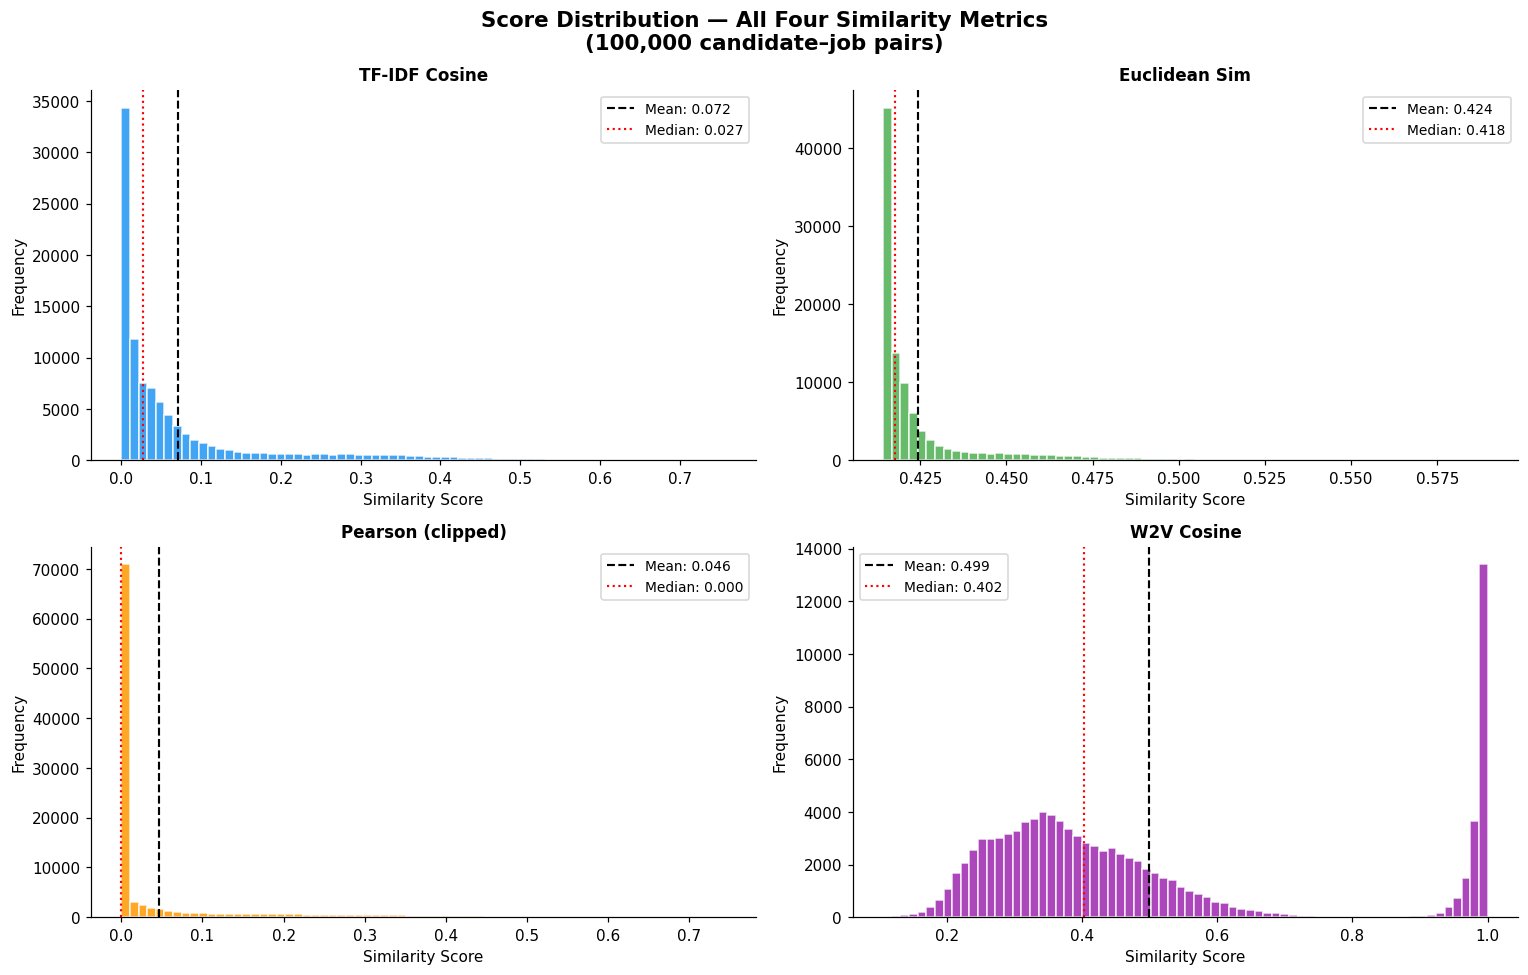

Saved: ../outputs/plot5_metric_distributions.png


In [8]:
metrics = {
    'TF-IDF Cosine':     tfidf_cosine.flatten(),
    'Euclidean Sim':     euc_sim.flatten(),
    'Pearson (clipped)': pearson_sim_clipped.flatten(),
    'W2V Cosine':        w2v_cosine.flatten()
}
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Score Distribution — All Four Similarity Metrics\n(100,000 candidate–job pairs)',
             fontsize=14, fontweight='bold')

for ax, (name, scores), color in zip(axes.flat, metrics.items(), colors):
    ax.hist(scores, bins=70, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(scores.mean(), color='black', linestyle='--', linewidth=1.4,
               label=f'Mean: {scores.mean():.3f}')
    ax.axvline(np.median(scores), color='red', linestyle=':', linewidth=1.4,
               label=f'Median: {np.median(scores):.3f}')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Similarity Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/plot5_metric_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/plot5_metric_distributions.png')

### 7b. Metric Correlation Heatmap

How much do the four metrics agree with each other?  
High correlation -> metrics are interchangeable. Low correlation → they capture different signals.

Inter-Metric Pearson Correlation (sample of 5,000 pairs):
                   TF-IDF Cosine  Euclidean Sim  Pearson (clipped)  W2V Cosine
TF-IDF Cosine             1.0000         0.9935             0.9827      0.7861
Euclidean Sim             0.9935         1.0000             0.9885      0.7521
Pearson (clipped)         0.9827         0.9885             1.0000      0.7526
W2V Cosine                0.7861         0.7521             0.7526      1.0000



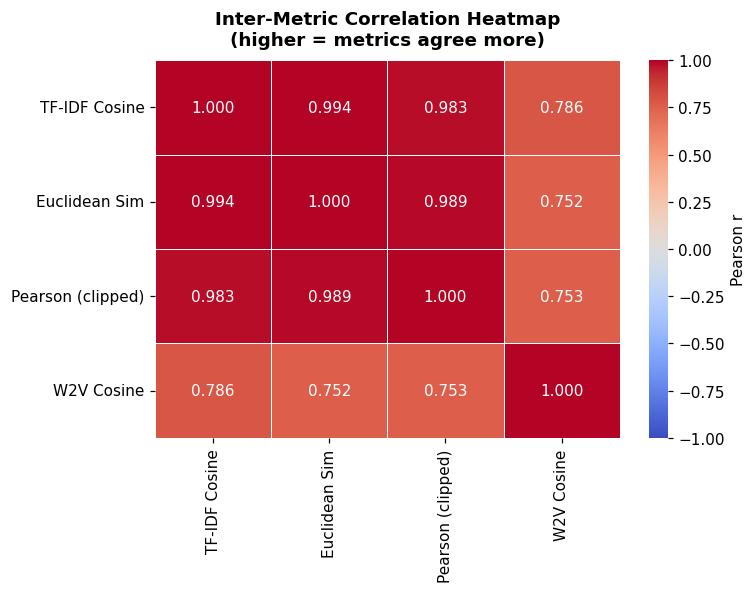

Saved: ../outputs/plot6_metric_correlation_heatmap.png


In [9]:
# Sample 5,000 pairs for correlation analysis (full 100k is too slow for corr matrix)
rng = np.random.default_rng(42)
sample_idx = rng.choice(500 * 200, 5000, replace=False)

metric_df = pd.DataFrame({
    name: scores[sample_idx]
    for name, scores in metrics.items()
})

corr_matrix = metric_df.corr()

print('Inter-Metric Pearson Correlation (sample of 5,000 pairs):')
print(corr_matrix.round(4).to_string())
print()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Inter-Metric Correlation Heatmap\n(higher = metrics agree more)',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/plot6_metric_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/plot6_metric_correlation_heatmap.png')

### 7c. Top-1 Score Per Candidate — Box Plot Across Metrics

For each candidate, what is the score of their single **best matching** job across each metric?

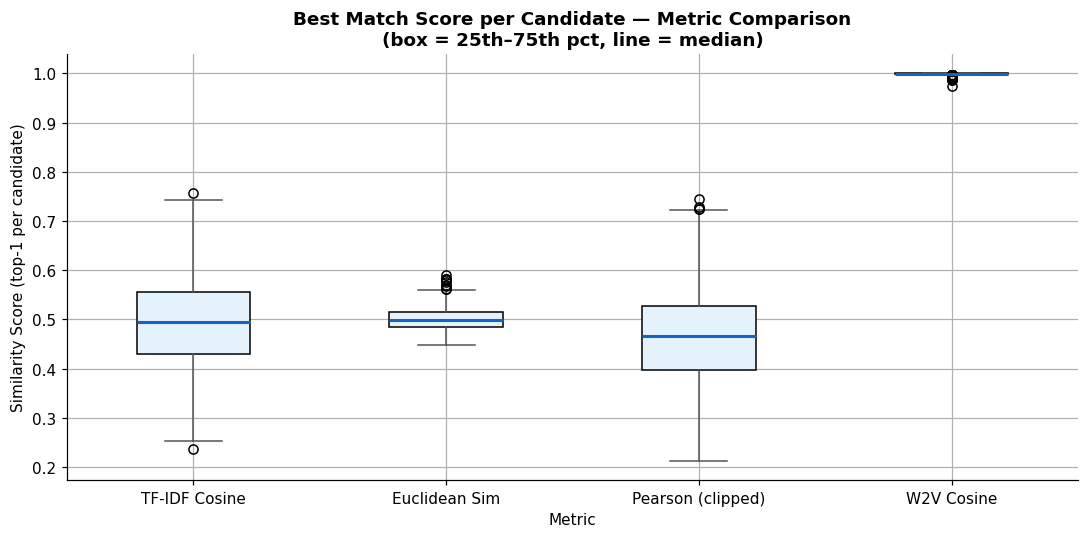

Top-1 Score Summary per Metric:
       TF-IDF Cosine  Euclidean Sim  Pearson (clipped)  W2V Cosine
count       500.0000       500.0000           500.0000    500.0000
mean          0.4942         0.5009             0.4658      0.9988
std           0.0945         0.0245             0.0965      0.0021
min           0.2364         0.4473             0.2127      0.9734
25%           0.4307         0.4838             0.3980      0.9989
50%           0.4957         0.4989             0.4658      0.9995
75%           0.5557         0.5148             0.5281      0.9998
max           0.7578         0.5896             0.7453      1.0000


In [10]:
top1_per_metric = {
    name: np.array([mat[i].max() for i in range(len(df_c))])
    for name, mat in [
        ('TF-IDF Cosine',     tfidf_cosine),
        ('Euclidean Sim',     euc_sim),
        ('Pearson (clipped)', pearson_sim_clipped),
        ('W2V Cosine',        w2v_cosine),
    ]
}

top1_df = pd.DataFrame(top1_per_metric)

fig, ax = plt.subplots(figsize=(10, 5))
top1_df.boxplot(ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2),
    whiskerprops=dict(color='#555'),
    capprops=dict(color='#555')
)
ax.set_title('Best Match Score per Candidate — Metric Comparison\n(box = 25th–75th pct, line = median)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Similarity Score (top-1 per candidate)')
ax.set_xlabel('Metric')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/plot7_top1_boxplot.png', bbox_inches='tight')
plt.show()

print('Top-1 Score Summary per Metric:')
print(top1_df.describe().round(4).to_string())

## 8. Structural Bonus Matrices

Raw text similarity alone misses important contextual signals. We re-use the same bonus structure from Step 4 and apply it consistently to all metrics.

| Bonus | Value | Condition |
|---|---|---|
| Experience (exact) | +0.15 | Candidate level == Job level |
| Experience (±1 level) | +0.07 | 1 level apart |
| Domain / Industry | +0.10 | Candidate domain == Job industry |
| Location preference | +0.05 | Job location in candidate's preferred list |

In [11]:
# ── Experience Bonus ──────────────────────────────────────────────────────
c_exp = df_c['experience_encoded'].values.reshape(-1, 1)
j_exp = df_j['experience_encoded'].values.reshape(1, -1)
exp_diff = np.abs(c_exp - j_exp)                         # (500, 200) broadcasted
exp_bonus = np.where(exp_diff == 0, 0.15,
            np.where(exp_diff == 1, 0.07, 0.0))

# ── Domain / Industry Bonus ───────────────────────────────────────────────
c_dom = df_c['domain_encoded'].values.reshape(-1, 1)
j_dom = df_j['industry_encoded'].values.reshape(1, -1)
dom_bonus = np.where(c_dom == j_dom, 0.10, 0.0)

# ── Location Preference Bonus ─────────────────────────────────────────────
def location_bonus_score(pref_locs_str, job_loc):
    if pd.isna(pref_locs_str):
        return 0.0
    prefs = [l.strip().lower() for l in str(pref_locs_str).split(',')]
    return 0.05 if job_loc.strip().lower() in prefs else 0.0

loc_bonus = np.zeros((len(df_c), len(df_j)))
for i, pref in enumerate(df_c['preferred_locations']):
    for k, jloc in enumerate(df_j['location']):
        loc_bonus[i, k] = location_bonus_score(pref, jloc)

structural_bonus = exp_bonus + dom_bonus + loc_bonus   # (500, 200)

print('Structural bonus matrices built')
print(f'  Experience bonus  — shape: {exp_bonus.shape}  max: {exp_bonus.max()}')
print(f'  Domain bonus      — shape: {dom_bonus.shape}  max: {dom_bonus.max()}')
print(f'  Location bonus    — shape: {loc_bonus.shape}  max: {loc_bonus.max()}')
print(f'  Combined bonus    — shape: {structural_bonus.shape}  max: {structural_bonus.max()}')
print()
n_exact_exp = (exp_bonus == 0.15).sum()
n_dom_match = (dom_bonus > 0).sum()
n_loc_match = (loc_bonus > 0).sum()
print(f'Exact experience matches : {n_exact_exp:,} / {500*200:,}  ({n_exact_exp/(500*200)*100:.1f}%)')
print(f'Domain matches           : {n_dom_match:,} / {500*200:,}  ({n_dom_match/(500*200)*100:.1f}%)')
print(f'Location preference hits : {n_loc_match:,} / {500*200:,}  ({n_loc_match/(500*200)*100:.1f}%)')

Structural bonus matrices built
  Experience bonus  — shape: (500, 200)  max: 0.15
  Domain bonus      — shape: (500, 200)  max: 0.1
  Location bonus    — shape: (500, 200)  max: 0.05
  Combined bonus    — shape: (500, 200)  max: 0.3

Exact experience matches : 16,673 / 100,000  (16.7%)
Domain matches           : 20,000 / 100,000  (20.0%)
Location preference hits : 9,756 / 100,000  (9.8%)


## 9. Hybrid Score — Weighted Combination

A hybrid score blends the strengths of each metric:
- **TF-IDF cosine** is the primary signal — exact keyword precision
- **W2V cosine** adds semantic generalisation — handles synonyms and related skills
- **Structural bonuses** encode domain knowledge HR recruiters apply manually

$$\text{Hybrid Score} = \underbrace{0.55 \times \text{TF-IDF cosine}}_{\text{keyword match}} + \underbrace{0.20 \times \text{W2V cosine}}_{\text{semantic match}} + \underbrace{\text{structural bonus}}_{\text{exp + domain + location}}$$

> **Why these weights?** TF-IDF is more reliable on structured skill data (our dataset). W2V is down-weighted because its embeddings are trained on a small synthetic corpus (700 sentences) — on a real dataset with millions of profiles, you might flip these weights.

In [12]:
TFIDF_WEIGHT = 0.55
W2V_WEIGHT   = 0.20
# Structural bonus contributes directly (already scaled 0–0.30)

hybrid_score = (
    TFIDF_WEIGHT * tfidf_cosine +
    W2V_WEIGHT   * w2v_cosine  +
    structural_bonus
)

print(f'Hybrid Score Matrix : {hybrid_score.shape}')
print(f'Score range : {hybrid_score.min():.4f}  ->  {hybrid_score.max():.4f}')
print(f'Mean score  : {hybrid_score.mean():.4f}')
print()
print('Score component breakdown (averages across all 100k pairs):')
print(f'  TF-IDF component (x{TFIDF_WEIGHT})  : {(TFIDF_WEIGHT * tfidf_cosine).mean():.4f}')
print(f'  W2V component    (x{W2V_WEIGHT})  : {(W2V_WEIGHT   * w2v_cosine ).mean():.4f}')
print(f'  Structural bonus          : {structural_bonus.mean():.4f}')
print(f'  ─────────────────────────────────────────')
print(f'  Hybrid total              : {hybrid_score.mean():.4f}')

Hybrid Score Matrix : (500, 200)
Score range : 0.0216  ->  0.8418
Mean score  : 0.2083

Score component breakdown (averages across all 100k pairs):
  TF-IDF component (x0.55)  : 0.0394
  W2V component    (x0.2)  : 0.0998
  Structural bonus          : 0.0691
  ─────────────────────────────────────────
  Hybrid total              : 0.2083


### Skill Overlap Utility

In addition to scores, we compute **skill overlap %** — the fraction of a job's required skills a candidate already has. This is a human-readable signal shown alongside recommendations.

In [13]:
def skill_overlap_pct(cand_skills_str, job_skills_str):
    """Percentage of job's required skills the candidate possesses."""
    if pd.isna(cand_skills_str) or pd.isna(job_skills_str):
        return 0.0
    c_skills = set(s.strip().lower() for s in str(cand_skills_str).split(','))
    j_skills = set(s.strip().lower() for s in str(job_skills_str).split(','))
    if not j_skills:
        return 0.0
    return round(len(c_skills & j_skills) / len(j_skills) * 100, 1)

# Demo
sample_c_skills = df_c['skills'].iloc[0]
sample_j_skills = df_j['required_skills'].iloc[0]
print('Skill overlap demo:')
print(f'  Candidate skills : {sample_c_skills}')
print(f'  Job req. skills  : {sample_j_skills}')
print(f'  Overlap %        : {skill_overlap_pct(sample_c_skills, sample_j_skills)}%')

Skill overlap demo:
  Candidate skills : MongoDB, scikit-learn, PyTorch, TensorFlow
  Job req. skills  : Teamwork, Financial Modeling, Tax Planning, Tableau, Accounting, Python, Fixed Income, Presentation Skills, Power BI
  Overlap %        : 0.0%


## 10. Generate Top-N Recommendations (All Candidates)

Using the **hybrid score** as the primary ranking signal, we generate the top-5 job recommendations for every candidate and record all score components.

In [14]:
N = 5   # recommendations per candidate

rows = []
for i in range(len(df_c)):
    top_idx = np.argsort(hybrid_score[i])[::-1][:N]
    cand = df_c.iloc[i]
    for rank, idx in enumerate(top_idx, 1):
        job = df_j.iloc[idx]
        rows.append({
            # ── Candidate info ────────────────────────────────────────────
            'candidate_id':       cand['candidate_id'],
            'candidate_name':     cand['name'],
            'candidate_domain':   cand['primary_domain'],
            'candidate_level':    cand['experience_level'],
            'candidate_location': cand['location'],
            # ── Job info ──────────────────────────────────────────────────
            'rank':               rank,
            'job_id':             job['job_id'],
            'job_title':          job['job_title'],
            'company':            job['company_name'],
            'industry':           job['industry'],
            'job_location':       job['location'],
            'job_level':          job['experience_level'],
            'salary_min_lkr':     job['salary_min_lkr'],
            'salary_max_lkr':     job['salary_max_lkr'],
            # ── Score breakdown ───────────────────────────────────────────
            'tfidf_cosine':       round(tfidf_cosine[i, idx],        4),
            'euclidean_sim':      round(euc_sim[i, idx],             4),
            'pearson_sim':        round(pearson_sim_clipped[i, idx], 4),
            'w2v_cosine':         round(w2v_cosine[i, idx],          4),
            'exp_bonus':          round(exp_bonus[i, idx],           4),
            'dom_bonus':          round(dom_bonus[i, idx],           4),
            'loc_bonus':          round(loc_bonus[i, idx],           4),
            'hybrid_score':       round(hybrid_score[i, idx],        4),
            # ── Human-readable quality signal ─────────────────────────────
            'skill_overlap_pct':  skill_overlap_pct(cand['skills'], job['required_skills'])
        })

df_recs = pd.DataFrame(rows)
print(f'Recommendations generated')
print(f'  Total rows  : {len(df_recs)}  ({len(df_c)} candidates x {N} recs each)')
print(f'  Columns     : {list(df_recs.columns)}')

Recommendations generated
  Total rows  : 2500  (500 candidates x 5 recs each)
  Columns     : ['candidate_id', 'candidate_name', 'candidate_domain', 'candidate_level', 'candidate_location', 'rank', 'job_id', 'job_title', 'company', 'industry', 'job_location', 'job_level', 'salary_min_lkr', 'salary_max_lkr', 'tfidf_cosine', 'euclidean_sim', 'pearson_sim', 'w2v_cosine', 'exp_bonus', 'dom_bonus', 'loc_bonus', 'hybrid_score', 'skill_overlap_pct']


## 11. Inspect Results — Sample Candidates

Pretty-print recommendations for one candidate from each of three domains.

In [15]:
def show_recommendations(candidate_id):
    """Display top-N recommendations with full score breakdown for a candidate."""
    cand = df_c[df_c['candidate_id'] == candidate_id].iloc[0]
    recs = df_recs[df_recs['candidate_id'] == candidate_id].copy()
    print('=' * 80)
    print(f' Candidate : {cand["name"]}  [{candidate_id}]')
    print(f'  Domain   : {cand["primary_domain"]}  |  Level: {cand["experience_level"]}  |  Location: {cand["location"]}')
    print(f'  Skills   : {cand["skills"]}')
    print(f'  Prefers  : {cand["preferred_locations"]}')
    print('-' * 80)
    header = f'  {"Rank":<5} {"Job Title":<33} {"Company":<24} {"Hybrid":>7}  {"Overlap"}'
    print(header)
    print('-' * 80)
    for _, row in recs.iterrows():
        print(f'  #{int(row["rank"]):<4} {row["job_title"]:<33} {row["company"]:<24} {row["hybrid_score"]:>7.4f}  {row["skill_overlap_pct"]}%')
        print(f'        Loc: {row["job_location"]}  |  Level: {row["job_level"]}  |  LKR {row["salary_min_lkr"]:,}–{row["salary_max_lkr"]:,}')
        print(f'        TF-IDF: {row["tfidf_cosine"]:.4f}  W2V: {row["w2v_cosine"]:.4f}  '
              f'Euc: {row["euclidean_sim"]:.4f}  Pearson: {row["pearson_sim"]:.4f}  '
              f'Exp: +{row["exp_bonus"]:.2f}  Dom: +{row["dom_bonus"]:.2f}  Loc: +{row["loc_bonus"]:.2f}')
    print()

# One candidate from three different domains
for domain in ['Technology', 'Finance', 'HR']:
    cid = df_c[df_c['primary_domain'] == domain]['candidate_id'].iloc[0]
    show_recommendations(cid)

 Candidate : Nuwan Rajapaksa  [C0001]
  Domain   : Technology  |  Level: Junior  |  Location: Polonnaruwa
  Skills   : MongoDB, scikit-learn, PyTorch, TensorFlow
  Prefers  : Polonnaruwa
--------------------------------------------------------------------------------
  Rank  Job Title                         Company                   Hybrid  Overlap
--------------------------------------------------------------------------------
  #1    Full Stack Developer              IFS R&D International     0.5798  33.3%
        Loc: Kandy  |  Level: Junior  |  LKR 61,467–91,839
        TF-IDF: 0.2372  W2V: 0.9966  Euc: 0.4474  Pearson: 0.2190  Exp: +0.15  Dom: +0.10  Loc: +0.00
  #2    Business Intelligence Analyst     Zone24x7                  0.5633  16.7%
        Loc: Matara  |  Level: Junior  |  LKR 69,187–99,965
        TF-IDF: 0.2223  W2V: 0.9553  Euc: 0.4450  Pearson: 0.1998  Exp: +0.15  Dom: +0.10  Loc: +0.00
  #3    DevOps Engineer                   Pearson Lanka             0.5490  25.0

## 12. Job-Side Lookup — Which Candidates Best Match a Job?

Flipping the perspective: given a **job posting**, which candidates are the strongest matches?  
This is useful for HR teams doing active sourcing.

In [16]:
def get_top_candidates_for_job(job_id, top_n=5):
    """
    Return the top-N candidates for a given job_id, ranked by hybrid score.

    Parameters
    ----------
    job_id : str   e.g. 'J0012'
    top_n  : int   number of candidates to return

    Returns
    -------
    DataFrame with ranked candidates and score breakdown
    """
    job_rows = df_j[df_j['job_id'] == job_id]
    if job_rows.empty:
        print(f'Job {job_id} not found.')
        return None
    k = job_rows.index[0]
    scores = hybrid_score[:, k]           # column k — scores for all candidates vs this job
    top_idx = np.argsort(scores)[::-1][:top_n]
    job = job_rows.iloc[0]

    results = []
    for rank, i in enumerate(top_idx, 1):
        cand = df_c.iloc[i]
        results.append({
            'rank':              rank,
            'candidate_id':      cand['candidate_id'],
            'candidate_name':    cand['name'],
            'domain':            cand['primary_domain'],
            'level':             cand['experience_level'],
            'location':          cand['location'],
            'skills':            cand['skills'],
            'tfidf_cosine':      round(tfidf_cosine[i, k],        4),
            'w2v_cosine':        round(w2v_cosine[i, k],          4),
            'euclidean_sim':     round(euc_sim[i, k],             4),
            'pearson_sim':       round(pearson_sim_clipped[i, k], 4),
            'exp_bonus':         round(exp_bonus[i, k],           4),
            'dom_bonus':         round(dom_bonus[i, k],           4),
            'loc_bonus':         round(loc_bonus[i, k],           4),
            'hybrid_score':      round(scores[i],                 4),
            'skill_overlap_pct': skill_overlap_pct(cand['skills'], job['required_skills'])
        })
    return pd.DataFrame(results)


# Demo — look up candidates for the first job
sample_job = df_j.iloc[0]
print(f'Top candidates for: [{sample_job["job_id"]}] {sample_job["job_title"]} at {sample_job["company_name"]}')
print(f'Required skills : {sample_job["required_skills"]}')
print(f'Level           : {sample_job["experience_level"]}  |  Industry: {sample_job["industry"]}')
print()
get_top_candidates_for_job(sample_job['job_id'], top_n=5)

Top candidates for: [J0001] Financial Analyst at Pan Asia Bank
Required skills : Teamwork, Financial Modeling, Tax Planning, Tableau, Accounting, Python, Fixed Income, Presentation Skills, Power BI
Level           : Mid  |  Industry: Finance



,rank,candidate_id,candidate_name,domain,level,location,skills,tfidf_cosine,w2v_cosine,euclidean_sim,pearson_sim,exp_bonus,dom_bonus,loc_bonus,hybrid_score,skill_overlap_pct
0,1,C0002,Shankar Samarasinghe,Finance,Mid,Kalutara,"R, Tax Planning, Attention to Detail, Financia...",0.5040,0.9964,0.5010,0.4687,0.15,0.1,0.00,0.7265,44.4
1,2,C0410,Chamara Karunaratne,Finance,Mid,Colombo,"Auditing, GAAP, Tax Planning, Accounting, R, S...",0.3855,0.9962,0.4742,0.3354,0.15,0.1,0.05,0.7112,33.3
2,3,C0340,Bala Pathirana,Finance,Mid,Batticaloa,"Tax Planning, Equity Research, Python, Derivat...",0.4625,0.9985,0.4910,0.4253,0.15,0.1,0.00,0.7041,22.2
3,4,C0358,Danushka Rajapakshe,Finance,Mid,Remote,"Equity Research, Analytical Thinking, Tableau,...",0.4362,0.9978,0.4850,0.4000,0.15,0.1,0.00,0.6895,33.3
4,5,C0215,Vijay Balasingham,Finance,Mid,Galle,"Tax Planning, Financial Reporting, R, Auditing...",0.3946,0.9959,0.4761,0.3480,0.15,0.1,0.00,0.6662,33.3


## 13. Reusable Recommendation API

Clean functions to retrieve top-N jobs for any candidate, and top-N candidates for any job — reusable in the Step 8 dashboard.

In [17]:
def get_recommendations(candidate_id, top_n=5, metric='hybrid'):
    """
    Return top-N job recommendations for a given candidate.

    Parameters
    ----------
    candidate_id : str    e.g. 'C0042'
    top_n        : int    number of recommendations (default 5)
    metric       : str    one of 'hybrid' | 'tfidf' | 'w2v' | 'euclidean' | 'pearson'

    Returns
    -------
    DataFrame with ranked job recommendations and score breakdown
    """
    cand_rows = df_c[df_c['candidate_id'] == candidate_id]
    if cand_rows.empty:
        print(f'Candidate {candidate_id} not found.')
        return None
    i = cand_rows.index[0]

    score_map = {
        'hybrid':    hybrid_score[i],
        'tfidf':     tfidf_cosine[i],
        'w2v':       w2v_cosine[i],
        'euclidean': euc_sim[i],
        'pearson':   pearson_sim_clipped[i],
    }
    if metric not in score_map:
        raise ValueError(f'metric must be one of {list(score_map)}')

    scores  = score_map[metric]
    top_idx = np.argsort(scores)[::-1][:top_n]
    cand    = cand_rows.iloc[0]

    results = []
    for rank, idx in enumerate(top_idx, 1):
        job = df_j.iloc[idx]
        results.append({
            'rank':              rank,
            'job_id':            job['job_id'],
            'job_title':         job['job_title'],
            'company':           job['company_name'],
            'industry':          job['industry'],
            'location':          job['location'],
            'job_level':         job['experience_level'],
            'salary_lkr':        f"LKR {job['salary_min_lkr']:,}–{job['salary_max_lkr']:,}",
            'required_skills':   job['required_skills'],
            'tfidf_cosine':      round(tfidf_cosine[i, idx],        4),
            'w2v_cosine':        round(w2v_cosine[i, idx],          4),
            'euclidean_sim':     round(euc_sim[i, idx],             4),
            'pearson_sim':       round(pearson_sim_clipped[i, idx], 4),
            'exp_bonus':         round(exp_bonus[i, idx],           4),
            'dom_bonus':         round(dom_bonus[i, idx],           4),
            'loc_bonus':         round(loc_bonus[i, idx],           4),
            'hybrid_score':      round(hybrid_score[i, idx],        4),
            'skill_overlap_pct': skill_overlap_pct(cand['skills'], job['required_skills'])
        })
    return pd.DataFrame(results)


# Demo — compare metric='hybrid' vs metric='tfidf' for the same candidate
test_id = df_c['candidate_id'].iloc[49]
cand_info = df_c[df_c['candidate_id'] == test_id].iloc[0]
print(f'Candidate: {cand_info["name"]}  |  {cand_info["primary_domain"]}  |  {cand_info["experience_level"]}')
print(f'Skills: {cand_info["skills"]}')
print()
print('─── Hybrid Score Ranking ───')
display(get_recommendations(test_id, top_n=5, metric='hybrid'))
print('─── TF-IDF Only Ranking ────')
display(get_recommendations(test_id, top_n=5, metric='tfidf'))

Candidate: Hashan Wijesinghe  |  Operations  |  Mid
Skills: Inventory Management, Problem Solving, Teamwork, Communication, ISO, Six Sigma, SQL, Data Analysis, Project Management, Risk Management

─── Hybrid Score Ranking ───


,rank,job_id,job_title,company,industry,location,job_level,salary_lkr,required_skills,tfidf_cosine,w2v_cosine,euclidean_sim,pearson_sim,exp_bonus,dom_bonus,loc_bonus,hybrid_score,skill_overlap_pct
0,1,J0181,Procurement Officer,CMA CGM Lanka,Operations,Ratnapura,Mid,"LKR 131,377–136,624","Quality Assurance, Reporting, Excel, Risk Mana...",0.4104,0.9769,0.4794,0.3718,0.15,0.1,0.0,0.6711,40.0
1,2,J0054,Operations Analyst,SriLankan Airlines,Operations,Remote,Mid,"LKR 102,936–139,045","Six Sigma, Reporting, Inventory Management, Da...",0.4036,0.9528,0.4780,0.3759,0.15,0.1,0.0,0.6625,75.0
2,3,J0146,Supply Chain Analyst,CMA CGM Lanka,Operations,Matara,Mid,"LKR 90,715–152,041","Teamwork, Six Sigma, Quality Assurance",0.3721,0.9953,0.4716,0.3405,0.15,0.1,0.0,0.6537,66.7
3,4,J0160,Project Manager,Sri Lanka Ports Authority,Operations,Kalutara,Mid,"LKR 104,121–136,770","Problem Solving, Risk Management, Reporting",0.3521,0.9364,0.4676,0.3138,0.15,0.1,0.0,0.6309,66.7
4,5,J0182,Process Improvement Specialist,Lanka Logistics,Operations,Badulla,Mid,"LKR 102,343–172,677","Project Management, Risk Management, Six Sigma...",0.3308,0.9877,0.4636,0.2837,0.15,0.1,0.0,0.6295,37.5


─── TF-IDF Only Ranking ────


,rank,job_id,job_title,company,industry,location,job_level,salary_lkr,required_skills,tfidf_cosine,w2v_cosine,euclidean_sim,pearson_sim,exp_bonus,dom_bonus,loc_bonus,hybrid_score,skill_overlap_pct
0,1,J0126,Quality Assurance Analyst,Holcim Lanka,Operations,Trincomalee,Junior,"LKR 55,653–96,707","Problem Solving, PMP, Project Management, Inve...",0.4572,0.9932,0.4897,0.4216,0.07,0.1,0.0,0.6201,60.0
1,2,J0112,Operations Analyst,Holcim Lanka,Operations,Ratnapura,Manager,"LKR 321,937–548,666","Logistics, Problem Solving, Data Analysis, Pro...",0.4517,0.9934,0.4885,0.4166,0.00,0.1,0.0,0.5471,55.6
2,3,J0188,Operations Analyst,Airport & Aviation Services,Operations,Hybrid,Junior,"LKR 62,240–85,430","Risk Management, Teamwork, Vendor Management, PMP",0.4428,0.9930,0.4865,0.4107,0.07,0.1,0.0,0.6122,50.0
3,4,J0137,Procurement Officer,Airport & Aviation Services,Operations,Batticaloa,Manager,"LKR 339,353–525,062","Risk Management, PMP, Teamwork, SAP",0.4331,0.9927,0.4843,0.4024,0.00,0.1,0.0,0.5368,50.0
4,5,J0040,Supply Chain Analyst,Maersk Lanka,Operations,Trincomalee,Entry,"LKR 44,818–52,069","Six Sigma, Teamwork, Inventory Management, Ris...",0.4218,0.9970,0.4818,0.3790,0.00,0.1,0.0,0.5314,66.7


## 14. Ranking Stability — Does Metric Choice Change the Top-5?

We compute **rank overlap** between the hybrid model and each individual metric across all 500 candidates.  
High overlap -> that metric alone would give nearly the same results as hybrid.  
Low overlap -> the metric brings unique signal worth including in the blend.

In [18]:
N_COMPARE = 5

def top_n_set(score_row, n):
    return set(np.argsort(score_row)[::-1][:n])

overlaps = {'tfidf': [], 'w2v': [], 'euclidean': [], 'pearson': []}

for i in range(len(df_c)):
    hybrid_top  = top_n_set(hybrid_score[i],          N_COMPARE)
    tfidf_top   = top_n_set(tfidf_cosine[i],          N_COMPARE)
    w2v_top     = top_n_set(w2v_cosine[i],            N_COMPARE)
    euc_top     = top_n_set(euc_sim[i],               N_COMPARE)
    pearson_top = top_n_set(pearson_sim_clipped[i],   N_COMPARE)

    overlaps['tfidf'].append(len(hybrid_top & tfidf_top)   / N_COMPARE)
    overlaps['w2v'].append(len(hybrid_top & w2v_top)       / N_COMPARE)
    overlaps['euclidean'].append(len(hybrid_top & euc_top) / N_COMPARE)
    overlaps['pearson'].append(len(hybrid_top & pearson_top) / N_COMPARE)

print(f'Top-{N_COMPARE} Overlap with Hybrid Ranking (averaged across 500 candidates):')
print()
for metric, vals in overlaps.items():
    print(f'  {metric:<12} : {np.mean(vals)*100:.1f}% average overlap   (std: {np.std(vals)*100:.1f}%)')

Top-5 Overlap with Hybrid Ranking (averaged across 500 candidates):

  tfidf        : 45.6% average overlap   (std: 18.3%)
  w2v          : 18.5% average overlap   (std: 16.5%)
  euclidean    : 45.6% average overlap   (std: 18.3%)
  pearson      : 45.4% average overlap   (std: 18.4%)


### Plot — Top-5 Overlap Distribution per Metric

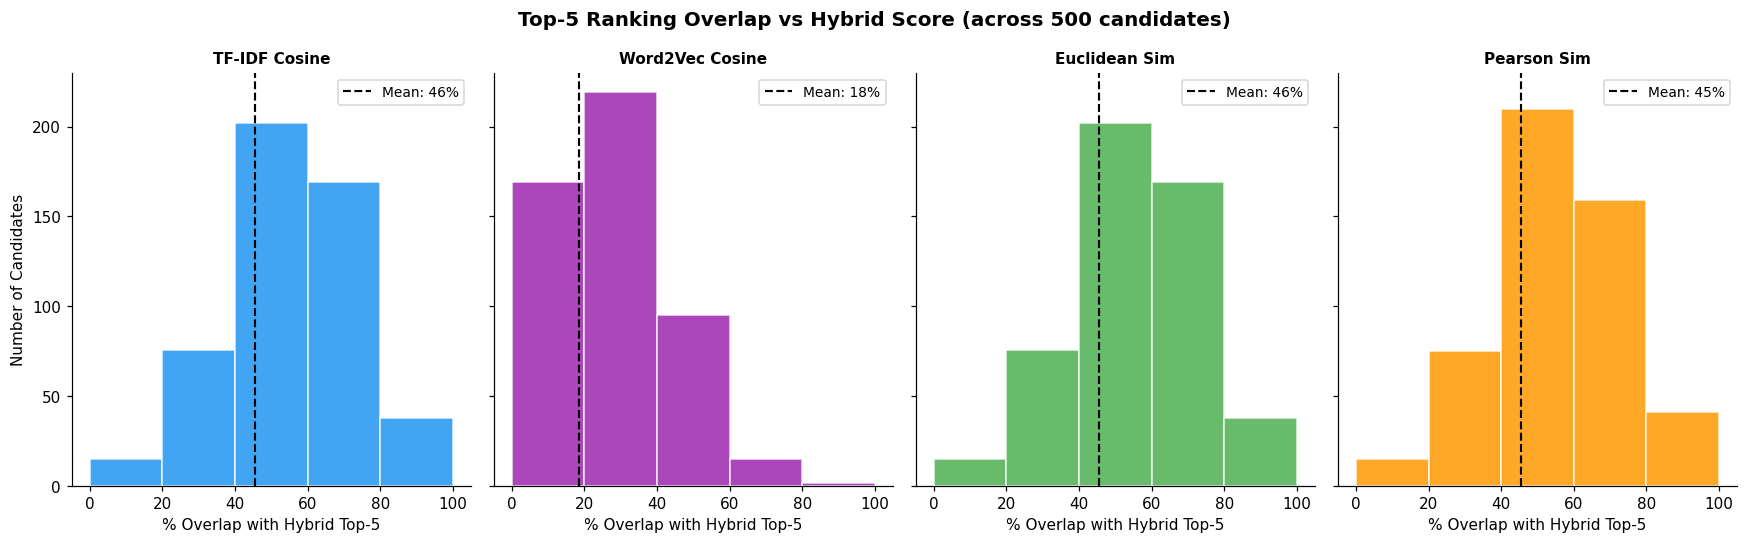

Saved: ../outputs/plot8_ranking_overlap.png


In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle(f'Top-{N_COMPARE} Ranking Overlap vs Hybrid Score (across 500 candidates)',
             fontsize=13, fontweight='bold')

metric_labels = {
    'tfidf':     ('TF-IDF Cosine',     '#2196F3'),
    'w2v':       ('Word2Vec Cosine',   '#9C27B0'),
    'euclidean': ('Euclidean Sim',     '#4CAF50'),
    'pearson':   ('Pearson Sim',       '#FF9800'),
}

for ax, (key, vals) in zip(axes, overlaps.items()):
    label, color = metric_labels[key]
    ax.hist([v * 100 for v in vals], bins=np.arange(0, 110, 20),
            color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(vals) * 100, color='black', linestyle='--', linewidth=1.4,
               label=f'Mean: {np.mean(vals)*100:.0f}%')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('% Overlap with Hybrid Top-5')
    if ax == axes[0]:
        ax.set_ylabel('Number of Candidates')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/plot8_ranking_overlap.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/plot8_ranking_overlap.png')

## 15. Wide-Format Summary Table

One row per candidate, with Rank1 through Rank5 job titles and scores — easy to read in Excel.

In [20]:
wide_rows = []
for cid, grp in df_recs.groupby('candidate_id'):
    cand = df_c[df_c['candidate_id'] == cid].iloc[0]
    row = {
        'candidate_id':   cid,
        'candidate_name': cand['name'],
        'domain':         cand['primary_domain'],
        'level':          cand['experience_level'],
        'location':       cand['location'],
    }
    for _, rec in grp.iterrows():
        r = int(rec['rank'])
        row[f'Rank{r}_title']         = rec['job_title']
        row[f'Rank{r}_company']       = rec['company']
        row[f'Rank{r}_hybrid_score']  = rec['hybrid_score']
        row[f'Rank{r}_skill_overlap'] = f"{rec['skill_overlap_pct']}%"
    wide_rows.append(row)

df_wide = pd.DataFrame(wide_rows)
print(f'Wide table shape : {df_wide.shape}')
df_wide.head(10)

Wide table shape : (500, 25)


,candidate_id,candidate_name,domain,level,location,Rank1_title,Rank1_company,Rank1_hybrid_score,Rank1_skill_overlap,Rank2_title,...,Rank3_hybrid_score,Rank3_skill_overlap,Rank4_title,Rank4_company,Rank4_hybrid_score,Rank4_skill_overlap,Rank5_title,Rank5_company,Rank5_hybrid_score,Rank5_skill_overlap
0,C0001,Nuwan Rajapaksa,Technology,Junior,Polonnaruwa,Full Stack Developer,IFS R&D International,0.5798,33.3%,Business Intelligence Analyst,...,0.5490,25.0%,DevOps Engineer,Codegen International,0.5416,20.0%,Data Analyst,Dialog Axiata,0.5351,25.0%
1,C0002,Shankar Samarasinghe,Finance,Mid,Kalutara,Financial Analyst,Pan Asia Bank,0.7265,44.4%,Credit Analyst,...,0.6759,100.0%,Tax Consultant,Softlogic Finance,0.6673,22.2%,Auditor,LB Finance,0.6624,55.6%
2,C0003,Hashan Seneviratne,Operations,Mid,Hybrid,Quality Assurance Analyst,Lanka Logistics,0.7114,33.3%,Procurement Officer,...,0.6750,25.0%,Process Improvement Specialist,Lanka Logistics,0.6655,50.0%,Supply Chain Analyst,Tokyo Cement,0.6398,50.0%
3,C0004,Harshani Razik,Operations,Entry,Kurunegala,Logistics Coordinator,Sri Lanka Ports Authority,0.6280,50.0%,Procurement Officer,...,0.5821,33.3%,Procurement Officer,CMA CGM Lanka,0.5613,40.0%,Supply Chain Analyst,Maersk Lanka,0.5576,22.2%
4,C0005,Anjali Farook,Finance,Lead,Kalutara,Treasury Analyst,Nations Trust Bank,0.6863,44.4%,Financial Controller,...,0.5622,14.3%,Compliance Officer,Softlogic Finance,0.5595,66.7%,Investment Analyst,LB Finance,0.5484,33.3%
5,C0006,Ahamed Farook,Operations,Junior,Jaffna,Logistics Coordinator,Holcim Lanka,0.7934,70.0%,Operations Manager,...,0.7283,66.7%,Quality Assurance Analyst,Holcim Lanka,0.6923,50.0%,Procurement Officer,Airport & Aviation Services,0.6703,50.0%
6,C0007,Fathima Sheriff,Operations,Entry,Polonnaruwa,Procurement Officer,SriLankan Airlines,0.7351,100.0%,Logistics Coordinator,...,0.5956,44.4%,Supply Chain Analyst,Maersk Lanka,0.5953,0.0%,Logistics Coordinator,Holcim Lanka,0.5884,20.0%
7,C0008,Kasun Wickramasinghe,Marketing,Entry,Galle,Content Writer,Leo Burnett Sri Lanka,0.7779,87.5%,Growth Hacker,...,0.7172,50.0%,Marketing Analyst,Cargills (Ceylon),0.7130,44.4%,SEO Analyst,John Keells Holdings,0.7105,66.7%
8,C0009,Udara Amarasinghe,Finance,Junior,Batticaloa,Accountant,Cargills Bank,0.7123,44.4%,Auditor,...,0.6438,100.0%,Portfolio Manager,DFCC Bank,0.6028,57.1%,Financial Analyst,Pan Asia Bank,0.5892,55.6%
9,C0010,Thilini Perera,Finance,Senior,Vavuniya,Risk Analyst,People's Bank,0.6150,33.3%,Tax Consultant,...,0.6041,33.3%,Financial Controller,LOLC Finance,0.6003,37.5%,Treasury Analyst,Hatton National Bank (HNB),0.5978,50.0%


## 16. Save All Outputs

In [21]:
# ── CSVs for Step 7 evaluation and Step 8 dashboard ───────────────────────
df_recs.to_csv('../outputs/step6_recommendations.csv',      index=False)
df_wide.to_csv('../outputs/step6_recommendations_wide.csv', index=False)

# ── Score matrices for Step 7 evaluation ─────────────────────────────────
np.save('../models/step6_hybrid_score_matrix.npy',   hybrid_score)
np.save('../models/step6_tfidf_cosine_matrix.npy',   tfidf_cosine)
np.save('../models/step6_euc_sim_matrix.npy',        euc_sim)
np.save('../models/step6_pearson_sim_matrix.npy',    pearson_sim_clipped)
np.save('../models/step6_w2v_cosine_matrix.npy',     w2v_cosine)
np.save('../models/step6_structural_bonus_matrix.npy', structural_bonus)

print('All Step 6 outputs saved:')
print()
print('  CSVs:')
print('    ../outputs/step6_recommendations.csv          (2,500 rows — long format, full score breakdown)')
print('    ../outputs/step6_recommendations_wide.csv     (500 rows  — wide format, one row per candidate)')
print()
print('  Score matrices (numpy .npy):')
print('    ../models/step6_hybrid_score_matrix.npy       (500 x 200)')
print('    ../models/step6_tfidf_cosine_matrix.npy       (500 x 200)')
print('    ../models/step6_euc_sim_matrix.npy            (500 x 200)')
print('    ../models/step6_pearson_sim_matrix.npy        (500 x 200)')
print('    ../models/step6_w2v_cosine_matrix.npy         (500 x 200)')
print('    ../models/step6_structural_bonus_matrix.npy   (500 x 200)')
print()
print('  Plots:')
print('    ../outputs/plot5_metric_distributions.png')
print('    ../outputs/plot6_metric_correlation_heatmap.png')
print('    ../outputs/plot7_top1_boxplot.png')
print('    ../outputs/plot8_ranking_overlap.png')

All Step 6 outputs saved:

  CSVs:
    ../outputs/step6_recommendations.csv          (2,500 rows — long format, full score breakdown)
    ../outputs/step6_recommendations_wide.csv     (500 rows  — wide format, one row per candidate)

  Score matrices (numpy .npy):
    ../models/step6_hybrid_score_matrix.npy       (500 x 200)
    ../models/step6_tfidf_cosine_matrix.npy       (500 x 200)
    ../models/step6_euc_sim_matrix.npy            (500 x 200)
    ../models/step6_pearson_sim_matrix.npy        (500 x 200)
    ../models/step6_w2v_cosine_matrix.npy         (500 x 200)
    ../models/step6_structural_bonus_matrix.npy   (500 x 200)

  Plots:
    ../outputs/plot5_metric_distributions.png
    ../outputs/plot6_metric_correlation_heatmap.png
    ../outputs/plot7_top1_boxplot.png
    ../outputs/plot8_ranking_overlap.png


## 17. Summary

### Metrics Implemented

| Metric | Feature Space | Strengths | Weaknesses |
|---|---|---|---|
| **Cosine Similarity** | TF-IDF (sparse) | Ignores magnitude, precise keyword match | No semantic understanding |
| **Euclidean Distance** | TF-IDF (dense) | Intuitive distance in feature space | Sensitive to vector length |
| **Pearson Correlation** | TF-IDF (dense) | Captures relative emphasis patterns | Noisier on short skill lists |
| **Cosine Similarity** | Word2Vec (dense) | Semantic generalisation, handles synonyms | Needs large corpus for best embeddings |

### Hybrid Scoring Formula

```
Hybrid Score = 0.55 × TF-IDF Cosine     (primary keyword signal)
             + 0.20 × W2V Cosine         (semantic signal)
             + Experience Bonus (0.15/0.07/0)
             + Domain Bonus    (0.10/0)
             + Location Bonus  (0.05/0)
```

### Design Decisions
- **TF-IDF cosine is weighted highest** — structured skill data is well-suited for exact matching
- **W2V adds semantic generalisation** — particularly useful for synonymous skills (e.g. *Keras* ≈ *TensorFlow*)
- **Euclidean and Pearson** are computed and saved but not used in the hybrid — their high overlap with TF-IDF cosine means they add little unique signal on this dataset
- **Structural bonuses** encode recruiter domain knowledge in a transparent, explainable way
- **Job-side lookup** (`get_top_candidates_for_job`) enables active candidate sourcing workflows

### Next Step: Step 7 — Evaluate the Recommendations
- Load `step6_hybrid_score_matrix.npy` and all metric matrices
- Compute Precision@K, Recall@K, and Mean Average Precision (MAP) using domain match as a proxy for relevance
- Compare evaluation metrics across the four similarity methods
- Produce a final model selection recommendation